**Question 1: Which countries' CO2 emissions are rising fastest, and which are falling?**

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.columns.tolist())
df[df["country"] == "United States"][["year", "co2"]].tail()

(50411, 79)
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_p

,year,co2
48003,2020,4689.954
48004,2021,5020.111
48005,2022,5055.403
48006,2023,4918.407
48007,2024,4904.120


In [4]:
# keep real countries only — OWID includes regions like "World" and "Asia"
# that have no ISO code or start with OWID_
countries = df[df["iso_code"].notna() & ~df["iso_code"].str.startswith("OWID")]

# pick the start year and the latest year with good coverage
start, end = 1990, countries["year"].max()
print("latest year:", end)

a = countries[countries["year"] == start].set_index("country")["co2"]
b = countries[countries["year"] == end].set_index("country")["co2"]

change = pd.DataFrame({"co2_1990": a, "co2_latest": b}).dropna()
change = change[change["co2_1990"] >= 20]  # at least 20 Mt in 1990 — adjust and note in README
change["pct_change"] = (change["co2_latest"] / change["co2_1990"] - 1) * 100

rising = change.sort_values("pct_change", ascending=False).head(10)
falling = change.sort_values("pct_change").head(10)
print(rising[["pct_change"]].round(0))
print(falling[["pct_change"]].round(0))

latest year: 2024
                      pct_change
country                         
Vietnam                   1642.0
India                      453.0
Malaysia                   435.0
Indonesia                  424.0
China                      395.0
Iraq                       370.0
Philippines                329.0
United Arab Emirates       328.0
Saudi Arabia               280.0
Iran                       276.0
                pct_change
country                   
Moldova              -85.0
Ukraine              -80.0
Estonia              -77.0
Lithuania            -65.0
Romania              -61.0
Bulgaria             -59.0
Czechia              -54.0
Slovakia             -53.0
Belarus              -49.0
United Kingdom       -48.0


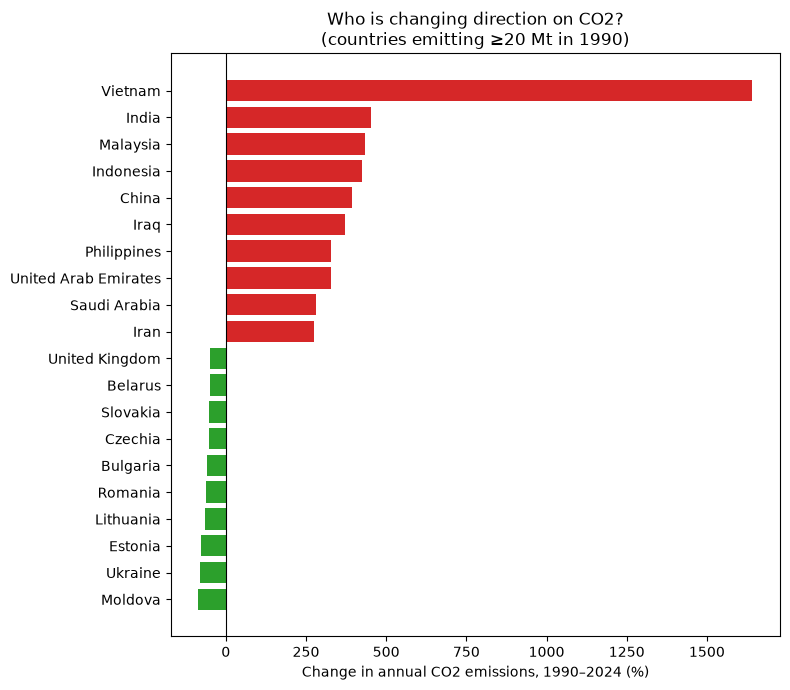

In [5]:
import matplotlib.pyplot as plt

both = pd.concat([falling, rising]).sort_values("pct_change")
colors = ["tab:green" if v < 0 else "tab:red" for v in both["pct_change"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(both.index, both["pct_change"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Change in annual CO2 emissions, {start}–{end} (%)")
ax.set_title("Who is changing direction on CO2?\n(countries emitting ≥20 Mt in 1990)")
plt.tight_layout()
plt.savefig("fig1_co2_change.png", dpi=150)